In [3]:
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import sys

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../..')
sys.path.insert(0, '../../../../..')

# Decoding
import suffix_pred.evalaution.decode_test_set_suffixes
importlib.reload(suffix_pred.evalaution.decode_test_set_suffixes)
from suffix_pred.evalaution.decode_test_set_suffixes import TestSetSuffixDecoder, DecodingConfig

# Evaluation metrics
import suffix_pred.evalaution.evalaution_metrics
importlib.reload(suffix_pred.evalaution.evalaution_metrics)
from suffix_pred.evalaution.evalaution_metrics import (evaluate_dls, dls_per_prefix_length, average_dls, load_decoded_suffixes)

# Model
import suffix_pred.models.K_UED_LSTM
importlib.reload(suffix_pred.models.K_UED_LSTM)
from suffix_pred.models.K_UED_LSTM import DropoutUncertaintyEncoderDecoderLSTM

In [4]:
# Model
file_path_model = '../../../../../../models/Sepsis/decision/Sepsis_UED_LSTM_v1_DA.pkl'
model = DropoutUncertaintyEncoderDecoderLSTM.load(file_path_model, dropout=0.1)

# Load the data
# Path to your pickle file (saved with torch.save)
file_path_test = '../../../../../../data/Sepsis/tensor_data/normal/sepsis_all_5_test.pkl'
# Load the dataset using torch.load
test_dataset = torch.load(file_path_test, weights_only=False)

Dynamic data set categories:  ([('concept:name', 18, {'Admission IC': 1, 'Admission NC': 2, 'CRP': 3, 'EOS': 4, 'ER Registration': 5, 'ER Sepsis Triage': 6, 'ER Triage': 7, 'IV Antibiotics': 8, 'IV Liquid': 9, 'LacticAcid': 10, 'Leucocytes': 11, 'Release A': 12, 'Release B': 13, 'Release C': 14, 'Release D': 15, 'Release E': 16, 'Return ER': 17}), ('org:group', 28, {'?': 1, 'A': 2, 'B': 3, 'C': 4, 'D': 5, 'E': 6, 'EOS': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'J': 12, 'K': 13, 'L': 14, 'M': 15, 'N': 16, 'O': 17, 'P': 18, 'Q': 19, 'R': 20, 'S': 21, 'T': 22, 'U': 23, 'V': 24, 'W': 25, 'X': 26, 'Y': 27}), ('lifecycle:transition', 3, {'EOS': 1, 'complete': 2})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {}), ('Leucocytes', 1, {}), ('CRP', 1, {}), ('LacticAcid', 1, {})])
Data set static categories:  ([('Age', 16, {'20': 1, '25': 2, '30': 3, '35': 4, '40': 5, '45': 6, '50': 7, '55': 8, '60': 9, '65': 10, '70': 11, '75': 12, '80':

In [5]:
# Step 1: Decode suffixes (probabilistic)
config = DecodingConfig(concept_name="concept:name",
                        eos_value="EOS",
                        probabilistic_samples=100,
                        num_processes=32)

decoder = TestSetSuffixDecoder(model=model, dataset=test_dataset, config=config)

mode = "probabilistic"
outputs = decoder.decode(mode=mode,
                         random_order=False,
                         cache_path="../../../../../../eval_results/Sepsis/decision_train/sepsis_ued_lstm_decision_train_outputs_fixed_tf.pkl",
                         reuse_cache=False,
                         parallel_inference=True,
                         num_processes=32)

print(f"Decoded {len(outputs)} prefix rows in '{mode}' mode")

# --- Step 2: Evaluate DLS from decoded outputs ---
prob_df = evaluate_dls(outputs, probabilistic_reduction="mean")
prob_per_prefix = dls_per_prefix_length(prob_df)

prob_avg = average_dls(prob_df)
prob_min = float(prob_df["dls_min"].mean())
prob_max = float(prob_df["dls_max"].mean())

print(f"Average DLS ({mode}, mean over T samples): {prob_avg:.4f}")
print(f"Average DLS min ({mode}): {prob_min:.4f}")
print(f"Average DLS max ({mode}): {prob_max:.4f}")

Probabilistic inference chunks:   0%|          | 0/30 [00:00<?, ?it/s]

Decoded 2648 prefix rows in 'probabilistic' mode
Average DLS (probabilistic, mean over T samples): 0.2481
Average DLS min (probabilistic): 0.0067
Average DLS max (probabilistic): 0.6434


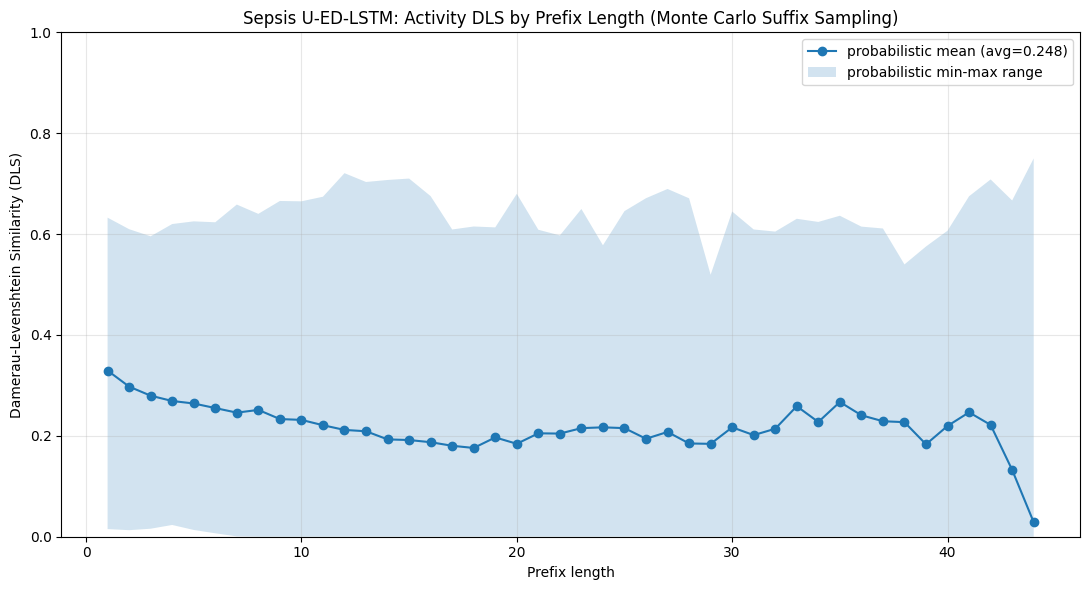

,mode,average_dls,average_dls_min,average_dls_max
0,probabilistic,0.248074,0.006675,0.643399


In [6]:
# One combined plot (single method requested: probabilistic only)
plt.figure(figsize=(11, 6))

plt.plot(prob_per_prefix["prefix_len"],
         prob_per_prefix["dls"],
         marker="o",
         label=f"probabilistic mean (avg={prob_avg:.3f})")

# Plot min/max range band for probabilistic decoding if available
if {"dls_min", "dls_max"}.issubset(prob_per_prefix.columns):
    plt.fill_between(prob_per_prefix["prefix_len"],
                     prob_per_prefix["dls_min"],
                     prob_per_prefix["dls_max"],
                     alpha=0.2,
                     label="probabilistic min-max range")

plt.title("Sepsis U-ED-LSTM: Activity DLS by Prefix Length (Monte Carlo Suffix Sampling)")
plt.xlabel("Prefix length")
plt.ylabel("Damerau-Levenshtein Similarity (DLS)")
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional summary table
summary = pd.DataFrame({
    "mode": [mode],
    "average_dls": [prob_avg],
    "average_dls_min": [prob_min],
    "average_dls_max": [prob_max],
}).sort_values("average_dls", ascending=False).reset_index(drop=True)
summary

In [7]:
# Load decoded outputs from pickle and inspect 5 example prefixes
cached_outputs = load_decoded_suffixes("../../../../../../eval_results/Sepsis/decision_train/sepsis_ued_lstm_decision_train_outputs_fixed_tf.pkl")

for row in cached_outputs[:5]:
    print(f"Case: {row['case_id']}  |  Prefix len: {row['prefix_len']}")
    print(f"  Prefix:         {row['prefix']}")
    print(f"  Target suffix:  {row['target_suffix']}")
    print(f"  Sampled suffixes ({len(row['decoded_suffixes'])}):")
    for i, s in enumerate(row["decoded_suffixes"][:5]):
        print(f"    [{i}] {s}")
    if len(row["decoded_suffixes"]) > 5:
        print(f"    ... and {len(row['decoded_suffixes']) - 5} more")
    print()

Case: CH  |  Prefix len: 1
  Prefix:         ['ER Registration']
  Target suffix:  ['ER Triage', 'ER Sepsis Triage', 'IV Antibiotics', 'Leucocytes', 'CRP', 'LacticAcid', 'Admission NC', 'Release A']
  Sampled suffixes (100):
    [0] ['ER Sepsis Triage', 'ER Triage', 'ER Sepsis Triage', 'Leucocytes', 'Leucocytes', 'IV Antibiotics', 'IV Antibiotics']
    [1] ['ER Triage', 'ER Sepsis Triage', 'Leucocytes', 'Leucocytes', 'CRP', 'IV Antibiotics', 'Admission NC', 'Leucocytes', 'Leucocytes', 'CRP', 'CRP', 'CRP', 'CRP', 'CRP', 'Leucocytes', 'Leucocytes', 'CRP', 'Leucocytes', 'CRP', 'Leucocytes']
    [2] ['ER Registration', 'Leucocytes', 'ER Triage', 'CRP', 'IV Liquid', 'Leucocytes', 'LacticAcid', 'IV Liquid', 'CRP', 'Admission NC', 'Leucocytes', 'Admission NC', 'Leucocytes', 'Leucocytes', 'Leucocytes', 'LacticAcid']
    [3] ['ER Triage', 'ER Sepsis Triage', 'ER Sepsis Triage', 'IV Liquid', 'CRP', 'IV Liquid', 'Admission NC', 'LacticAcid', 'CRP', 'CRP', 'CRP', 'CRP', 'CRP']
    [4] ['ER Triage'